# Annotation 0.1

## Introduction

Here the previous lung annotation and the stages of annotation are inspected.

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(glue)
library(here)
library(tidyverse)
library(Seurat)
library(presto)
library(igraph)
library(ggraph)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp

Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, isoyear, mday, minute

## Parameters

In [3]:
source(here::here("misc/paths.R"))

Rows: 20 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): donor_id, study_id, disease_group, sex, age, sars-cov-2_antemortem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load data

In [4]:
se_files <- c("se-combined-endothelial.rds", "se-combined-fibroblasts.rds",
              "se-combined-immune.rds", "se-combined-smc.rds")

se_ls <- lapply(se_files, function(i) {
    se <- "{annot_sc}/se_objects/{i}" %>%
        glue::glue() %>%
        here::here() %>%
        readRDS(file = .)
    DefaultAssay(se) <- "RNA"
    se
})

se <- merge(se_ls[[1]], y = se_ls[2:4])

In [5]:
meta_t <- "{annot_sc}/se_objects/se_lymphos/se-combined-tcells_annot_meta_woIntegration.rds" %>%
    glue::glue() %>%
    here::here() %>%
    readRDS(.)

meta_b <- "{annot_sc}/se_objects/se_lymphos/se-combined-Bcells&PCs_annot_meta_woIntegration.rds" %>%
    glue::glue() %>%
    here::here() %>%
    readRDS(.)

meta_tb <- bind_rows(meta_t, meta_b)

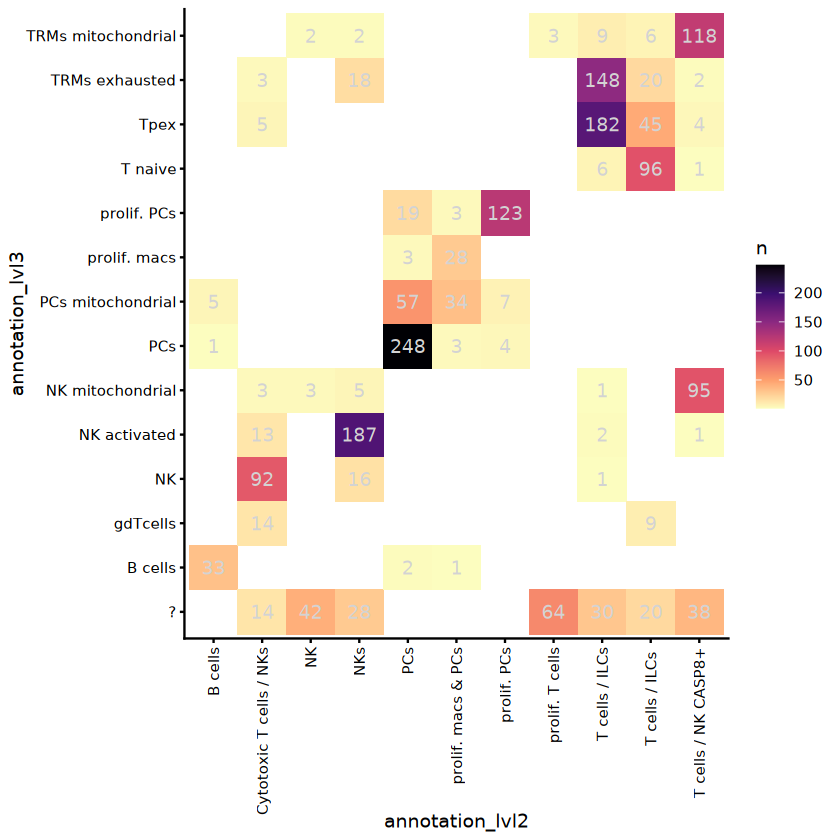

In [6]:
meta_tb %>%
    dplyr::count(annotation_lvl2, annotation_lvl3) %>%
    ggplot(aes(x = annotation_lvl2, y = annotation_lvl3, fill = n, label = n)) +
    geom_tile() +
    geom_text(color = "lightgrey") +
    scale_fill_viridis_c(option = "magma", direction = -1) + 
    theme_classic() +
    theme(axis.text.x = element_text(hjust = 1, vjust = 0.5, angle = 90))

In [7]:
tb_lvl3 <- meta_tb %>%
    tibble::rownames_to_column("bc") %>%
    dplyr::select(bc, annotation_lvl3) %>%
    mutate(bc = str_replace(bc, "^(acute|akut|chronic|control|prolonged)_", ""))

knitr::kable(table(tb_lvl3$annotation_lvl3))



|Var1               | Freq|
|:------------------|----:|
|?                  |  236|
|B cells            |   36|
|gdTcells           |   23|
|NK                 |  109|
|NK activated       |  203|
|NK mitochondrial   |  107|
|PCs                |  256|
|PCs mitochondrial  |  103|
|prolif. macs       |   31|
|prolif. PCs        |  145|
|T naive            |  103|
|Tpex               |  236|
|TRMs exhausted     |  191|
|TRMs mitochondrial |  140|

In [8]:
se@meta.data <- se@meta.data %>%
    tibble::rownames_to_column("bc") %>%
    left_join(tb_lvl3 %>% select(bc, annotation_lvl3), by = "bc") %>%
    mutate(annotation_lvl3 = case_when(
        is.na(annotation_lvl3) ~ annotation_lvl2,
        annotation_lvl3 == "?" ~ annotation_lvl2,
        TRUE ~ annotation_lvl3)) %>%
    tibble::column_to_rownames("bc")

## Reprocessing

Since we now have merged all the data we are going to re-process the data in order to capture the overall biological variability specific for this subset.

Re-normalize, scale and find new variable features specific for this subset:

In [9]:
se <- Seurat::NormalizeData(se, verbose = FALSE) %>%
    Seurat::FindVariableFeatures(selection.method = "vst", nfeatures = 3000) %>% 
    Seurat::ScaleData(verbose = FALSE) %>% 
    Seurat::RunPCA(pc.genes = .@var.genes, npcs = 50, verbose = FALSE)

set.seed(123)
se <- se %>% Seurat::RunUMAP(reduction = "pca", dims = 1:50)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
11:23:49 UMAP embedding parameters a = 0.9922 b = 1.112

11:23:49 Read 25744 rows and found 50 numeric columns

11:23:49 Using Annoy for neighbor search, n_neighbors = 30

11:23:49 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:23:52 Writing NN index file to temp file /scratch_tmp/64810682/Rtmpp5Gyjf/file27d031251c36e

11:23:52 Searching Annoy index using 1 thread, search_k = 3000

11:23:58 Annoy recall = 100%

11:23:59 Commencing smooth kNN distance calibration using 1 thread
 with t

## Dendrogram of annotation hierarchy

In [10]:
out_dir <- "~/SP-COVID/snRNAseq/0-annotation/out/plots"

predicted_to_major <- list(immune = c("Macrophage", "Natural Killer", "Intermediate Monocyte", "Classical Monocyte", "Basophil/Mast 1"),
                           endo   = c("Vein", "Artery", "Capillary", "Capillary Aerocyte", "Lymphatic", "Capillary Intermediate 1"),
                           fibro  = c("Alveolar Fibroblast", "Adventitial Fibroblast", "Myofibroblast"),
                           smc    = c("Pericyte", "Airway Smooth Muscle", "Vascular Smooth Muscle"))

major_type_names <- c(immune = "Immune", endo = "Endothelial", fibro = "Fibroblasts", smc = "Smooth muscle cells")

palette <- c("Root" = "#0173B2", "Major Type" = "#029E73",
             "Condition" = "#DE8F05", "Lvl 2" = "#D55E00", "Lvl 3" = "#CC78BC")

for (m_type in names(predicted_to_major)) {
    
  major_type_full <- major_type_names[m_type]
  
  sub_meta <- se@meta.data %>% 
    filter(predicted.id %in% predicted_to_major[[m_type]])
  
  if (nrow(sub_meta) == 0) {
    warning(paste("No cells found for", m_type, "- skipping"))
    next
  }
  
  sub_meta <- sub_meta %>%
    mutate(
      cond_suffix = str_extract(annotation_condition, "[^-]+$"),
      adj_lvl3 = ifelse(annotation_lvl2 == annotation_lvl3, NA, annotation_lvl3)
    )
  
  is_endo <- m_type == "endo"
  
  if (is_endo) {
    edges <- rbind(
      sub_meta %>% mutate(from = "snRNA-seq dataset", to = major_type_full) %>% select(from, to),
      sub_meta %>% mutate(from = major_type_full) %>% select(from, to = annotation_condition),
      sub_meta %>% select(from = annotation_condition, to = annotation_lvl2),
      sub_meta %>% filter(!is.na(adj_lvl3)) %>% select(from = annotation_lvl2, to = adj_lvl3)
    ) %>% distinct()
  } else {
    edges <- rbind(
      sub_meta %>% mutate(from = "snRNA-seq dataset", to = major_type_full) %>% select(from, to),
      sub_meta %>% mutate(from = major_type_full) %>% select(from, to = annotation_lvl2),
      sub_meta %>% filter(!is.na(adj_lvl3)) %>% select(from = annotation_lvl2, to = adj_lvl3)
    ) %>% distinct()
  }
  
  all_nodes <- unique(c(edges$from, edges$to))
  leaf_nodes <- all_nodes[!(all_nodes %in% edges$from)]
  
  node_info <- data.frame(name = all_nodes) %>%
    mutate(
      level_name = case_when(
        name == "snRNA-seq dataset" ~ "Root",
        name == major_type_full ~ "Major Type",
        name %in% sub_meta$annotation_condition ~ "Condition",
        name %in% sub_meta$annotation_lvl2 ~ "Lvl 2",
        TRUE ~ "Lvl 3"
      )
    )
  
  node_info <- node_info %>%
    rowwise() %>%
    mutate(
      cell_count = if(name == "snRNA-seq dataset") nrow(se@meta.data) else 
                   sum(name == major_type_full | 
                       sub_meta$annotation_condition == name | sub_meta$annotation_lvl2 == name | 
                       sub_meta$annotation_lvl3 == name, na.rm = TRUE),
      
      display_label = if(name %in% leaf_nodes && !name %in% c("snRNA-seq dataset", major_type_full)) {
        relevant_conds <- sub_meta %>%
          filter(annotation_lvl2 == name | annotation_lvl3 == name) %>%
          pull(cond_suffix) %>% unique() %>% sort() %>% paste(collapse = ", ")
        paste0(name, " (", relevant_conds, ", n=", cell_count, ")")
      } else {
        paste0(name, " (n=", cell_count, ")")
      }
    ) %>% ungroup()
  
  g <- graph_from_data_frame(edges, vertices = node_info)
  
  is_immune <- m_type == "immune"
  font_size <- if(is_immune) 7 else 5
  y_expansion <- if(is_immune) c(1.2, -4.5) else c(1.2, -1.5)
  save_width  <- if(is_immune) 80 else 45
  save_height <- if(is_immune) 38 else 22
  
  lay <- create_layout(g, layout = 'sugiyama')
  
  if (is_immune) {
    lay$y[lay$level_name == "Lvl 2"]      <- lay$y[lay$level_name == "Lvl 2"] - 0.7
    lay$y[lay$level_name == "Lvl 3"]      <- lay$y[lay$level_name == "Lvl 3"] - 1.5
  }
  
  p <- ggraph(lay) +
    geom_edge_diagonal(color = "grey60", alpha = 0.7, width = 0.8) +
    geom_node_point(aes(color = level_name, size = cell_count)) +
    geom_node_text(aes(label = display_label, color = level_name), 
                   size = font_size, fontface = "bold", 
                   hjust = 0, nudge_y = 0.1) + 
    scale_color_manual(values = palette, guide = "none") +
    scale_size_continuous(range = c(3, 12), guide = "none") +
    coord_flip(clip = "off") + 
    scale_y_reverse() + 
    theme_void() +
    expand_limits(y = y_expansion) + 
    theme(
      legend.position = "none",
      plot.margin = margin(50, 1200, 50, 50) 
    )
  
  ggsave(file.path(out_dir, paste0("annotation_hierarchy_", m_type, ".svg")), 
         p, width = save_width, height = save_height, bg = "white", limitsize = FALSE)
}

## Session information

In [11]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggraph_2.2.2        igraph_2.2.2        presto_1.0.0       
 [4] data.table_1.18.2.1 Rcpp_1.1.1          Seurat_5.4.0       
 [7] SeuratObject_5.3.0  sp_2.2-1            lubridate_1.9.5    
[10] forcats_1.0